# HIPAA Breach Data Analysis

Author: Wendy Lacan


**Input**: data/processed/breach_report_features.csv


**Output**: reports/figures/03_*.png | reports/key_findings.txt | data/processed/gap_summary.csv

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

PALETTE = ['#2A5E9C',"#5683B9", '#8cc5e3', '#E8A838', "#D94F3D", '#6BAF6B', "#9368C5"]
HACKING_C = '#D94F3D'
PHYS_C    = '#8cc5e3'
ACCENT    = '#E8A838'
DARK      = '#2A5E9C'

In [128]:
df = pd.read_csv('../data/processed/breach_report_features.csv')
df['breach_submission_date'] = pd.to_datetime(df['breach_submission_date'])
df['year'] = df['breach_submission_date'].dt.year

# excludes partial years for trend analysis
df_full =df[df['year'].between(2013, 2025)].copy() 

findings = []

print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
df.head()

Loaded: 6,029 rows, 41 columns
Year range: 2013 - 2026


,name_of_covered_entity,state,covered_entity_type,individuals_affected,breach_submission_date,type_of_breach,raw_location_of_breached_informatio,business_associate_present,web_description,year,...,quarter,days_since_epoch,ba_present,entity_business_associate,entity_health_plan,entity_healthcare_clearing_house,entity_healthcare_provider,region,breach_type_gap,location_gap
0,Ko-Kwel Wellness Center,OR,Healthcare Provider,543,2026-02-03,Hacking/IT Incident,Network Server,Yes,NaN,2026,...,1,4773,1,False,False,False,True,West,Technical Safeguard Failure,Technical Safeguard Failure
1,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,TN,Healthcare Provider,1341,2026-01-30,Unauthorized Access/Disclosure,Other,Yes,NaN,2026,...,1,4769,1,False,False,False,True,South,Administrative Safeguard Failure,Unclassified
2,Baltimore City Health Department,MD,Healthcare Provider,2597,2026-01-28,Hacking/IT Incident,Network Server,Yes,NaN,2026,...,1,4767,1,False,False,False,True,South,Technical Safeguard Failure,Technical Safeguard Failure
3,Deschutes County Health Services,OR,Healthcare Provider,1305,2026-01-22,Hacking/IT Incident,Network Server,Yes,NaN,2026,...,1,4761,1,False,False,False,True,West,Technical Safeguard Failure,Technical Safeguard Failure
4,Bay Area Community Health,CA,Healthcare Provider,9912,2026-01-16,Hacking/IT Incident,Network Server,Yes,"The covered entity (CE), Bay Area Community He...",2026,...,1,4755,1,False,False,False,True,West,Technical Safeguard Failure,Technical Safeguard Failure


### 1. Frequency Analysis

Frequency analysis establishes the baseline distribution of breach types and safeguard failures across the dataset, identifying the most common breach categories and whether these patterns remain consistent across entity types.

#### 1.1 Breach Type Distribution

In [129]:
type_counts = df['primary_breach_type'].value_counts()
type_pct = (type_counts / len(df)*100).round(2)

print("Breach type counts:")
print(type_counts.to_string())
print("\nBreach type %:")
print(type_pct.to_string())

Breach type counts:
primary_breach_type
Hacking/IT Incident               3648
Unauthorized Access/Disclosure    1429
Theft                              629
Loss                               179
Improper Disposal                   97
Other                               44
Unknown                              3

Breach type %:
primary_breach_type
Hacking/IT Incident               60.51
Unauthorized Access/Disclosure    23.70
Theft                             10.43
Loss                               2.97
Improper Disposal                  1.61
Other                              0.73
Unknown                            0.05


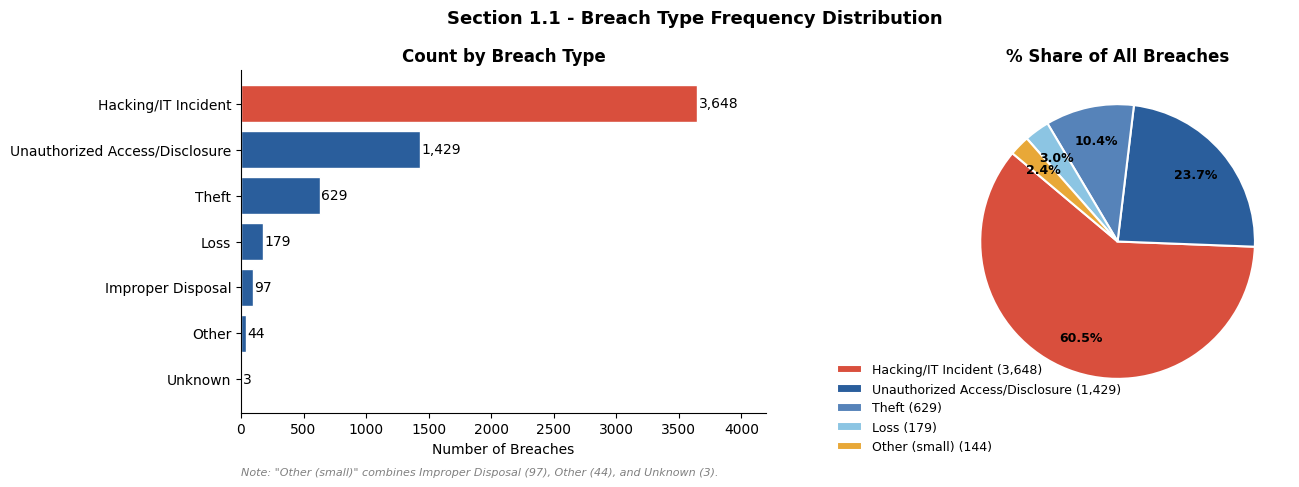


Key findings: [1.1] Most common breach type: 'Hacking/IT Incident' - 3,648 breaches (60.51% of all records)


In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Section 1.1 - Breach Type Frequency Distribution', fontweight='bold', fontsize=13)

# Bar Chart
colors = [HACKING_C if t == 'Hacking/IT Incident' else DARK for t in type_counts.index]
bars = axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color=colors[::-1], edgecolor='white')
# colors[::-1] is applied when drawing since type_counts is reversed for the horizontal display

axes[0].set_xlabel('Number of Breaches')
axes[0].set_title('Count by Breach Type', fontweight= 'bold')
axes[0].set_xlim(0, type_counts.values.max() * 1.15)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].annotate('Note: "Other (small)" combines Improper Disposal (97), Other (44), and Unknown (3).', xy=(0.0, -0.18),
                 xycoords='axes fraction', fontsize=8, color='gray', style='italic')

for bar, val in zip(bars, type_counts.values[::-1]):
                    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                                 f'{val:,}', va='center', fontsize=10)

# Pie Chart
threshold = 0.02
mask = type_counts / type_counts.sum() < threshold
grouped = type_counts.copy()
other_total = grouped[mask].sum()
grouped = grouped[~mask]
if other_total > 0:
        grouped['Other (small)'] = other_total

wedge_colors = []
palette_iter = iter([c for c in PALETTE if c != HACKING_C])
for t in grouped.index:
    if t == 'Hacking/IT Incident':
        wedge_colors.append(HACKING_C)
    else:
        wedge_colors.append(next(palette_iter))

wedges, texts, autotexts = axes[1].pie(
   grouped.values, 
   autopct='%1.1f%%',
   colors=wedge_colors,
   startangle=140,
   pctdistance=0.75,
   wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')

axes[1].legend(
        wedges,
        [f"{label} ({val:,})" for label, val in zip(grouped.index, grouped.values)],
        loc='lower left',
        bbox_to_anchor=(-0.35, -0.15),
        fontsize=9,
        frameon=False
)
        
axes[1].set_title('% Share of All Breaches', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_1a_breach_type_frequency.png', bbox_inches='tight')
plt.show()

top_type = type_counts.index[0]
top_pct = type_pct.iloc[0]
findings.append(f"[1.1] Most common breach type: '{top_type}' - {type_counts.iloc[0]:,} breaches ({top_pct}% of all records)")
print(f"\nKey findings: {findings[-1]}")

Hacking/IT incidents are color-coded red to visually trace the dominant threat vector across all analyses. At 60.5% of all reported breaches, hacking is now the clear majority breach type which is a significant shift from the physical breach dominated early years of the dataset. 

#### 1.2 Safeguard Failures by Entity Type

In [131]:
gap_entity = df.groupby(['covered_entity_type', 'breach_type_gap']).size().unstack(fill_value=0)
gap_entity_pct = gap_entity.div(gap_entity.sum(axis=1), axis=0) * 100

print("Safeguard failure counts by entity type:")
gap_entity

Safeguard failure counts by entity type:


breach_type_gap,Administrative Safeguard Failure,Physical/Administrative Safeguard Failure,Physical/Technical Safeguard Failure,Technical Safeguard Failure,Unclassified
covered_entity_type,,,,,
Business Associate,183,8,98,563,10
Health Plan,302,7,50,414,9
Healthcare Clearing House,5,1,1,6,0
Healthcare Provider,936,81,659,2663,28


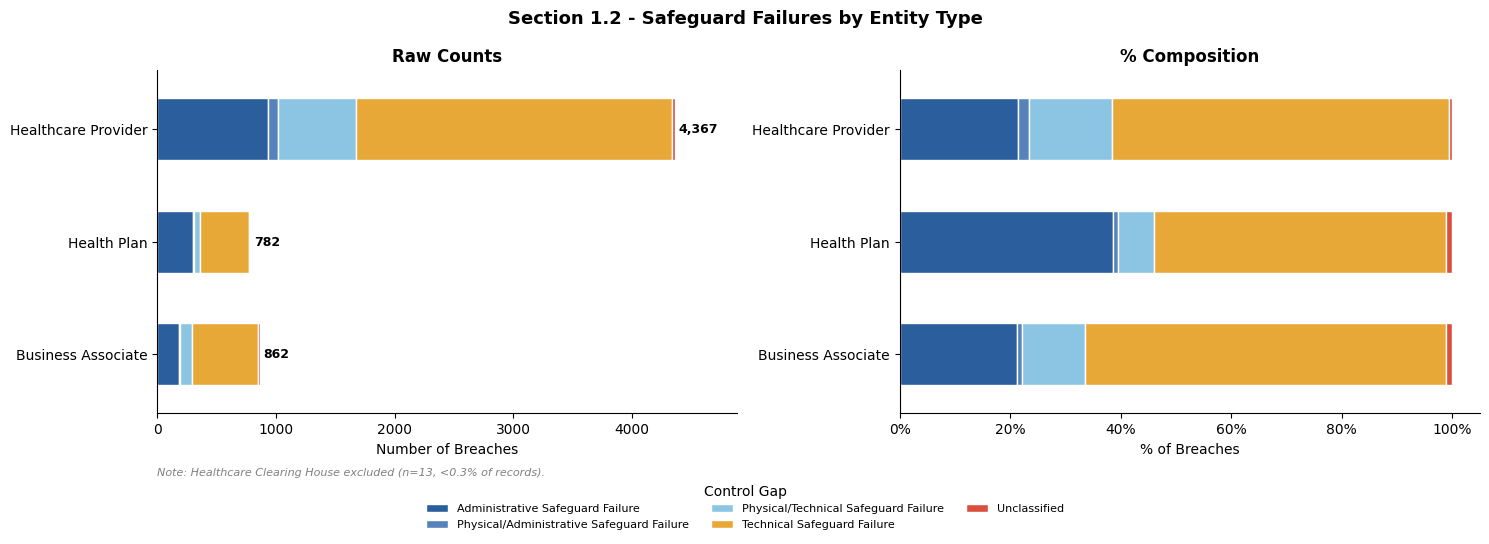


Key Finding: [1.2] Technical Safeguard Failure dominates across all entity types (Business Associate: 65.3%, Health Plan: 52.9%). Health Plans show a notably higher Administrative Safeguard Failure (38.6%) vs Business Associates (21.2%), suggesting weaker policy and access controls in plan administration.


In [132]:
# Drop near-zero entity before plotting
entities_to_drop = gap_entity[gap_entity.sum(axis=1) < 50].index
gap_entity_clean = gap_entity.drop(index=entities_to_drop)
gap_entity_pct_clean = gap_entity_pct.drop(index=entities_to_drop)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Section 1.2 - Safeguard Failures by Entity Type', fontweight='bold', fontsize=13)

# Left stacked bar
gap_entity_clean.plot(kind='barh', ax=axes[0], stacked= True, color=PALETTE[:len(gap_entity_clean.columns)], 
                edgecolor='white', width=0.55)
axes[0].set_title('Raw Counts', fontweight='bold')
axes[0].set_xlabel('Number of Breaches')
axes[0].set_ylabel('')
axes[0].annotate('Note: Healthcare Clearing House excluded (n=13, <0.3% of records).', xy=(0.0, -0.18), xycoords='axes fraction', fontsize=8, color='gray', style='italic')

axes[0].tick_params(axis='y', rotation=0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].get_legend().remove()

totals= gap_entity_clean.sum(axis=1)
for i, (entity, total) in enumerate(totals.items()):
    axes[0].text(total + 30, i, f'{total:,}', va='center', fontsize=9, fontweight='bold')

axes[0].set_xlim(0, totals.max() * 1.12)


# Rigt Stacked bar
gap_entity_pct_clean.plot(kind='barh', ax=axes[1], color=PALETTE[:len(gap_entity_clean.columns)], edgecolor='white', stacked=True, width=0.55)
axes[1].set_title('% Composition', fontweight='bold')
axes[1].set_xlabel('% of Breaches')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', rotation=0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

handles, labels = axes[1].get_legend_handles_labels()
axes[1].get_legend().remove()
fig.legend(handles, labels, title='Control Gap', fontsize=8, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig('../reports/figures/03_1b_safeguard_by_entity.png', bbox_inches='tight', dpi=150)
plt.show()

tech_col = 'Technical Safeguard Failure'
admin_col = 'Administrative Safeguard Failure'

ba_tech_pct = gap_entity_pct.loc['Business Associate', tech_col]
hp_tech_pct = gap_entity_pct.loc['Health Plan', tech_col]
hp_admin_pct = gap_entity_pct.loc['Health Plan', admin_col]
ba_admin_pct = gap_entity_pct.loc['Business Associate', admin_col]

findings.append(
    f"[1.2] Technical Safeguard Failure dominates across all entity types (Business Associate: {ba_tech_pct:.1f}%, Health Plan: {hp_tech_pct:.1f}%). "
    f"Health Plans show a notably higher Administrative Safeguard Failure ({hp_admin_pct:.1f}%) vs Business Associates ({ba_admin_pct:.1f}%), suggesting weaker policy and access controls in plan administration."
)
print(f"\nKey Finding: {findings[-1]}")

Technical Safeguard Failure dominates but the composition chart reveals meaningful differences. Business Associates have the highest concentration of technical failure consistent with their role processing large volumes of electronic data across multiple covered entities. Health Plans stand out for their relatively higher Administrative Safeguard Failure, suggesting weaker policy controls and access management in plan administration. 

#### 1.3 Breach Type & Location Co-Occurrence Heatmap

In [133]:
btype_cols= [c for c in df.columns if c.startswith('breach_type_') and c != 'breach_type_gap']
loc_cols = [c for c in df.columns if c.startswith('location_') and c != 'location_gap']

print(f"Breach type indicator columns: {len(btype_cols)}")
print(f"Location indicator columns: {len(loc_cols)}")

Breach type indicator columns: 7
Location indicator columns: 8


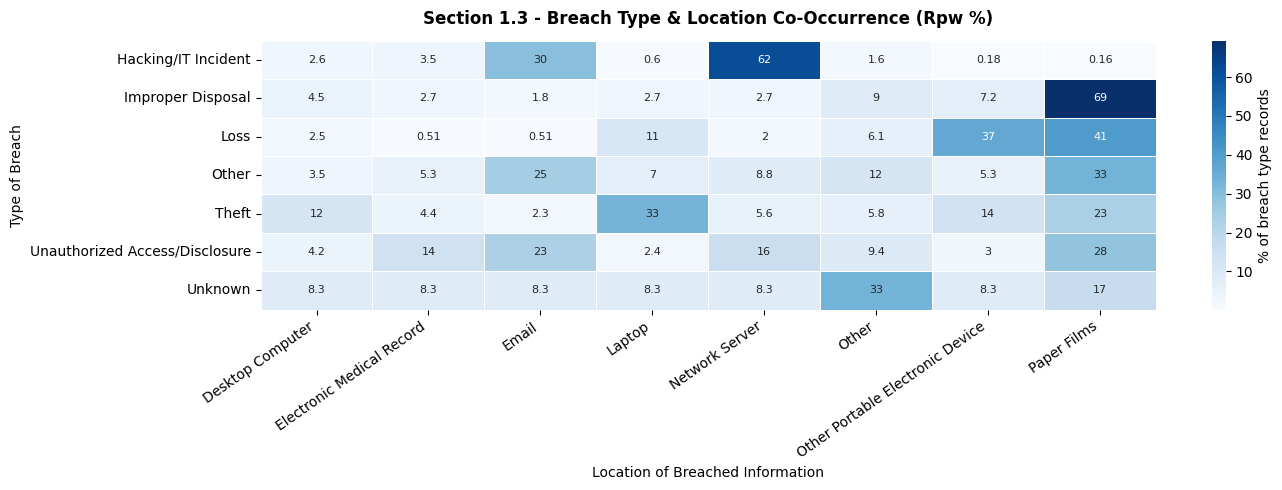

Key finding: [1.3] Hacking/IT incidents co-occur predominantly with Network Server and Email locations, indicating infrastructure and communication channel vulnerabilities are the primary technical attack surface.


In [134]:
cooc = pd.DataFrame(
    {lc: [int((df[bt].astype(bool) & df[lc].astype(bool)).sum()) for bt in btype_cols] for lc in loc_cols},
    index=btype_cols
).astype(float)

def clean_labels(s, prefix):
    return s.replace(prefix + '_', '').replace('_', ' ').title()

cooc.index = [clean_labels(c, 'breach_type') for c in cooc.index]
cooc.columns = [clean_labels(c, 'location') for c in cooc.columns]

index_fixes = {'Hacking It Incident': 'Hacking/IT Incident', 'Unauthorized Access Disclosure': 'Unauthorized Access/Disclosure'}

cooc.index = [index_fixes.get(l, l) for l in cooc.index]

cooc_norm = cooc.div(cooc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cooc_norm, annot=True, fmt='.2g', annot_kws={'size':8}, cmap='Blues', ax=ax, linewidths=0.4, cbar_kws={'label': '% of breach type records'})
ax.set_title('Section 1.3 - Breach Type & Location Co-Occurrence (Rpw %)', fontweight='bold', pad = 12)
ax.set_xlabel('Location of Breached Information')
ax.set_ylabel('Type of Breach')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/03_1c_cooccurence_heatmap.png', bbox_inches='tight')
plt.show()

findings.append("[1.3] Hacking/IT incidents co-occur predominantly with Network Server and Email locations, indicating infrastructure and communication channel vulnerabilities are the primary technical attack surface.")
print(f"Key finding: {findings[-1]}")

The co-occurence heatmap crosses breach type against location, showing distinct attack surfaces for each breach category. Hacking/IT incidents concentrate overwhelmingly on Network Server (62%) and Email (30%) which reflects infrastructure and communication channel vulnerabilities. Physical breaches tell a different story: Theft clusters on Laptop (33%), Loss on Paper/Films (41%), and Improper Disposal almost entirely on Paper/Films (69%). These patterns point to fundamentally different control gaps with technical safeguards for hacking, and physical handling and disposal procedures for the remaining categories.

### 2. Impact Analysis

Frequency counts alone can be misleading, since highly frequent breaches affecting few individuals presents a different risk profile than one that is rare yet catastrophic. This section measures severity along with frequency and examines whether third-party business associate involvement increases breach impact. 

#### 2.1 Median Individuals Affected by Breach Type

In [135]:
impact = df.groupby('primary_breach_type')['individuals_affected'].agg(
    Median='median',
    Mean='mean',
    Total='sum',
    Count='count'
).sort_values('Median', ascending=False).reset_index()

print("Impact by breach type:")
impact

Impact by breach type:


,primary_breach_type,Median,Mean,Total,Count
0,Hacking/IT Incident,8394.0,155028.755208,565544899,3648
1,Theft,2182.0,27200.764706,17109281,629
2,Other,2062.0,14638.022727,644073,44
3,Improper Disposal,2000.0,21080.309278,2044790,97
4,Unauthorized Access/Disclosure,1708.0,20889.874038,29851630,1429
5,Loss,1658.0,13966.357542,2499978,179
6,Unknown,953.0,956.333333,2869,3


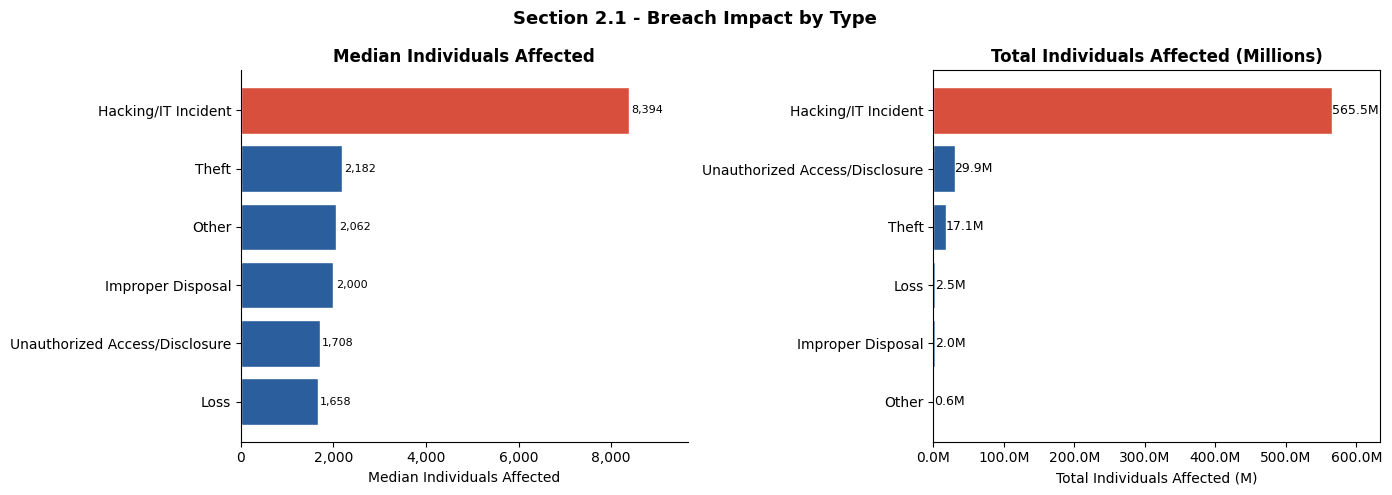


Key finding: [2.1] 'Hacking/IT Incident' has the highest median individuals affected per breach (8,394), making it the highest-severity breach category by impact.


In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 2.1 - Breach Impact by Type', fontweight='bold', fontsize=13)

impact_plot = impact[impact['primary_breach_type'] != 'Unknown'].iloc[::-1]

# Left: Median bar chart
colors = [HACKING_C if t == 'Hacking/IT Incident' else DARK
          for t in impact_plot['primary_breach_type']]
bars = axes[0].barh(impact_plot['primary_breach_type'], impact_plot['Median'], color=colors, edgecolor='white')
axes[0].set_title('Median Individuals Affected', fontweight='bold')
axes[0].set_xlabel('Median Individuals Affected')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_xlim(0, impact_plot['Median'].max() * 1.15)
for bar in bars:
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=8)

# Right: Total bar chart
total_impact = impact_plot.set_index('primary_breach_type')['Total'].sort_values(ascending=True)
colors2 = [HACKING_C if t == 'Hacking/IT Incident' else DARK for t in total_impact.index]
bars2 = axes[1].barh(total_impact.index, total_impact.values / 1e6, color=colors2, edgecolor='white')
axes[1].set_title('Total Individuals Affected (Millions)', fontweight='bold')
axes[1].set_xlabel('Total Individuals Affected (M)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
axes[1].set_xlim(0, total_impact.values.max() / 1e6 * 1.12)
for bar in bars2:
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/03_2a_impact_by_type.png', bbox_inches='tight')
plt.show()

top_impact_type = impact.iloc[0]['primary_breach_type']
top_impact_median = int(impact.iloc[0]['Median'])
findings.append(f"[2.1] '{top_impact_type}' has the highest median individuals affected per breach ({top_impact_median:,}), making it the highest-severity breach category by impact.")
print(f"\nKey finding: {findings[-1]}")

Median is preferred over mean because the distribution is heavily right-skewed by mega-breaches. A small number of very large breaches inflate mean values significantly, making median a more representative measure of the typical breach in each category. 


The left panel shows that Hacking/IT Incident stands apart from all other breach types with a median of 8,394 individuals affected, roughly 4x the next highest category which the right panel further reinforces. Despite competing breach types having hundreds of incidents each, hacking accounts for 565.5M of the ~618M total individuals affected across the entire dataset. This combination of the highest typical severity and the greatest aggregate impact identifies Technical Safeguard Failure as the most critical control gap. 

#### 2.2 Distribution Plots (Log Scale)

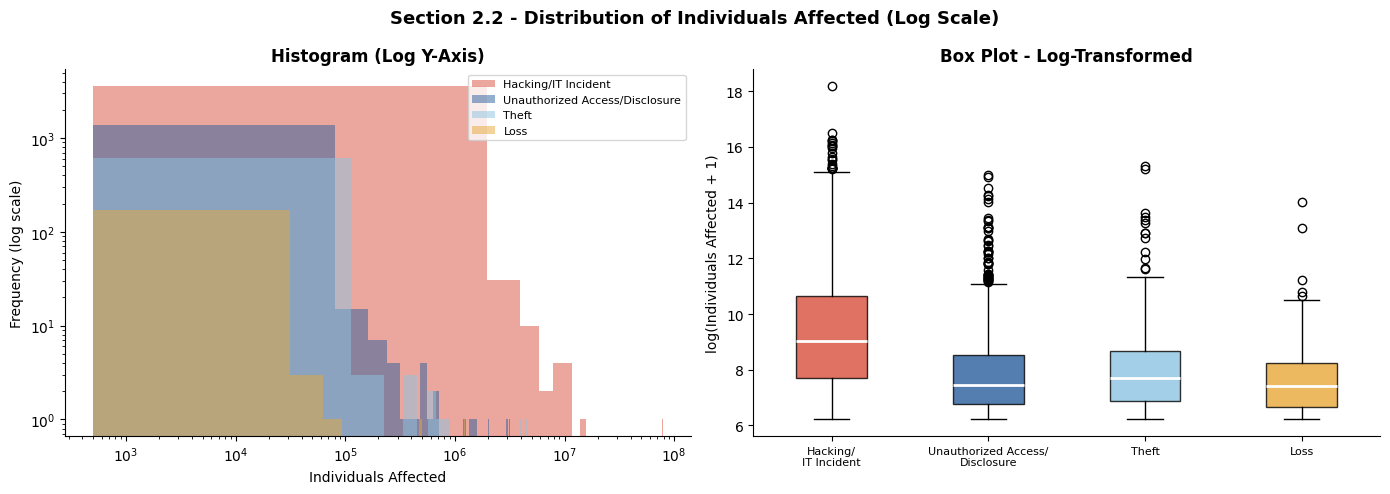


Key Finding: [2.2] Hacking/IT Incident has a higher log-scale median breach size (9.04) vs Unauthorized Access/Disclosure (7.44), and a wider IQR - confirming greater variability and more catastrophic outliers.


In [137]:
breach_types_plot = ['Hacking/IT Incident', 'Unauthorized Access/Disclosure', 'Theft', 'Loss']
colors_dist = [HACKING_C, DARK, PHYS_C, ACCENT]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 2.2 - Distribution of Individuals Affected (Log Scale)', fontweight='bold', fontsize=13)

for bt, color in zip(breach_types_plot, colors_dist):
    subset = df[df['primary_breach_type'] == bt]['individuals_affected']
    subset.plot(kind='hist', bins=40, alpha=0.5, color=color, label=bt, ax=axes[0], log=True)
axes[0].set_xlabel('Individuals Affected')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Histogram (Log Y-Axis)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_xscale('log')
axes[0].spines[['top', 'right']].set_visible(False)

bp_data = [df[df['primary_breach_type'] == bt]['log_individuals_affected'].dropna().values for bt in breach_types_plot]
bp = axes[1].boxplot(
    bp_data, 
    tick_labels=[b.replace('/', '/\n') for b in breach_types_plot], 
    patch_artist=True, 
    medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors_dist):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_ylabel('log(Individuals Affected + 1)')
axes[1].set_title('Box Plot - Log-Transformed', fontweight='bold')
axes[1].tick_params(axis='x', labelsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/03_2b_distribution_plots.png', bbox_inches='tight')
plt.show()

hack_median = df[df['primary_breach_type'] == 'Hacking/IT Incident']['log_individuals_affected'].median()
ua_median = df[df['primary_breach_type'] == 'Unauthorized Access/Disclosure']['log_individuals_affected'].median()
findings.append(f"[2.2] Hacking/IT Incident has a higher log-scale median breach size ({hack_median:.2f}) vs Unauthorized Access/Disclosure ({ua_median:.2f}), and a wider IQR - confirming greater variability and more catastrophic outliers.")
print(f"\nKey Finding: {findings[-1]}")

The log-transformed box plots normalize the extreme skew caused by mega-breaches. Even on a log-scale, hacking incidents show a wider spread and higher median than all breach types shown. This confirms that hacking not only occurs more frequently, but also produces more variability in scale, including the most catastrophic outcomes. 

#### 2.3 Business Associate Involvement vs. Breach Size

In [138]:
ba_impact = df.groupby('ba_present')['individuals_affected'].agg(
    Median='median',
    Mean='mean',
    Count='count'
).reset_index()
ba_impact['Label'] = ba_impact['ba_present'].map({0: 'No BA Involvement', 1: 'BA Involved'})

no_ba = df[df['ba_present'] == 0]['individuals_affected'].dropna()
ba = df[df['ba_present'] == 1]['individuals_affected'].dropna()
stat, p = stats.mannwhitneyu(ba, no_ba, alternative='greater')
print(f"Mann-Whitney U statistic: {stat:.0f}")
print(f"p-value: {p:.4f}")
print(f"Interpretation: {'Statistically significant - BA-involved breaches are larger (p < 0.001)' if p < 0.05 else 'Not statistically significant (p >= 0.05)'}")
ba_impact

Mann-Whitney U statistic: 4081920
p-value: 0.0001
Interpretation: Statistically significant - BA-involved breaches are larger (p < 0.001)


,ba_present,Median,Mean,Count,Label
0,0,3859.0,82746.304483,4194,No BA Involvement
1,1,4500.0,147498.375477,1835,BA Involved


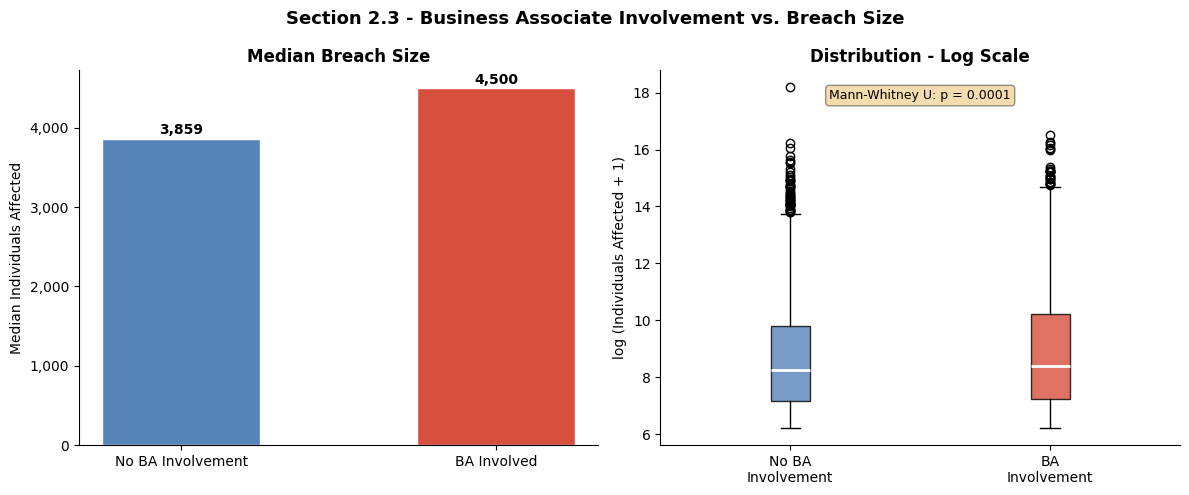


Key findings: [2.3] BA-involved breaches have a median of 4,500 individuals affected vs 3,859 without BA involvement - difference is statistically significant (p < 0.001).


In [139]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Section 2.3 - Business Associate Involvement vs. Breach Size', fontweight='bold', fontsize=13)

bars = axes[0].bar(
    ba_impact['Label'], ba_impact['Median'],
    color=[PALETTE[1], HACKING_C], edgecolor='white', width=0.5
)
axes[0].set_ylabel('Median Individuals Affected')
axes[0].set_title('Median Breach Size', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, 
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')

bp_ba = axes[1].boxplot(
    [df[df['ba_present'] == 0]['log_individuals_affected'].dropna(),
     df[df['ba_present'] == 1]['log_individuals_affected'].dropna()],
     tick_labels=['No BA\nInvolvement', 'BA\nInvolvement'],
     patch_artist=True, 
     medianprops=dict(color='white', linewidth=2)
)
bp_ba['boxes'][0].set_facecolor(PALETTE[1])
bp_ba['boxes'][0].set_alpha(0.8)
bp_ba['boxes'][1].set_facecolor(HACKING_C)
bp_ba['boxes'][1].set_alpha(0.8)
axes[1].set_ylabel('log (Individuals Affected + 1)')
axes[1].set_title('Distribution - Log Scale', fontweight='bold')
axes[1].text(0.5, 0.95, f'Mann-Whitney U: p = {p:.4f}', transform=axes[1].transAxes, ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor=ACCENT, alpha=0.4))
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/03_2c_ba_involvement_impact.png', bbox_inches='tight')
plt.show()

ba_no = int(ba_impact[ba_impact['ba_present'] == 0]['Median'].iloc[0])
ba_yes = int(ba_impact[ba_impact['ba_present'] == 1]['Median'].iloc[0])
sig = 'statistically significant (p < 0.001)' if p < 0.05 else f'not statistically significant (p= {p:.3f})'
findings.append(f"[2.3] BA-involved breaches have a median of {ba_yes:,} individuals affected vs {ba_no:,} without BA involvement - difference is {sig}.")
print(f"\nKey findings: {findings[-1]}")

The Mann-Whitney U test is used instead of a t-test because `individuals_affected` is non-normally distributed even after log transformation. A non-parametric test makes no distributional assumptions and is appropriate for this heavily right-skewed data. 

The result is statistically significant (p < 0.001), meaning BA-involved breaches are systematically larger than those without BA involvement. When a business associate is in scope, the breach tends to affect more individual which is likely because BAs often handle data in bulk across multiple covered entities. From a compliance standpoint, this suggests BA oversight and contractual controls (e.g, Business Associate Agreements) are a high-leverage control point for limiting breach impact.

### 3. Trend Analysis

Trend analysis tests whether the threat landscape has shifted meaningfully over the 2013-2025 period. The central hypotheses are that hacking incidents are increasing as healthcare digitizes and physical breaches are declining as organizations improve physical safeguard compliance. Linear regression provides a quantified, defensible measure of each trend. 

#### 3.1 Increase in Hacking Incidents

In [140]:
yearly_type = df_full.groupby(['year', 'primary_breach_type']).size().unstack(fill_value=0)
yearly_total = df_full.groupby('year').size()

years = yearly_type.index.values
hack_counts = yearly_type['Hacking/IT Incident'].values
hack_share = hack_counts / yearly_total.values * 100

slope, intercept, r, p_val, _ = stats.linregress(years, hack_counts)
trend_sig = 'significant upward trend' if (slope > 0 and p_val < 0.05) else 'no significant trend'

print(f"Linear regression - Hacking count vs Year:")
print(f"Slope:      {slope:.2f} additional breaches/year")
print(f"R²:         {r**2:.3f}")
print(f"p-value:    {p_val:.6f}")
print(f"Trend:      {trend_sig}")

Linear regression - Hacking count vs Year:
Slope:      40.83 additional breaches/year
R²:         0.538
p-value:    0.004310
Trend:      significant upward trend


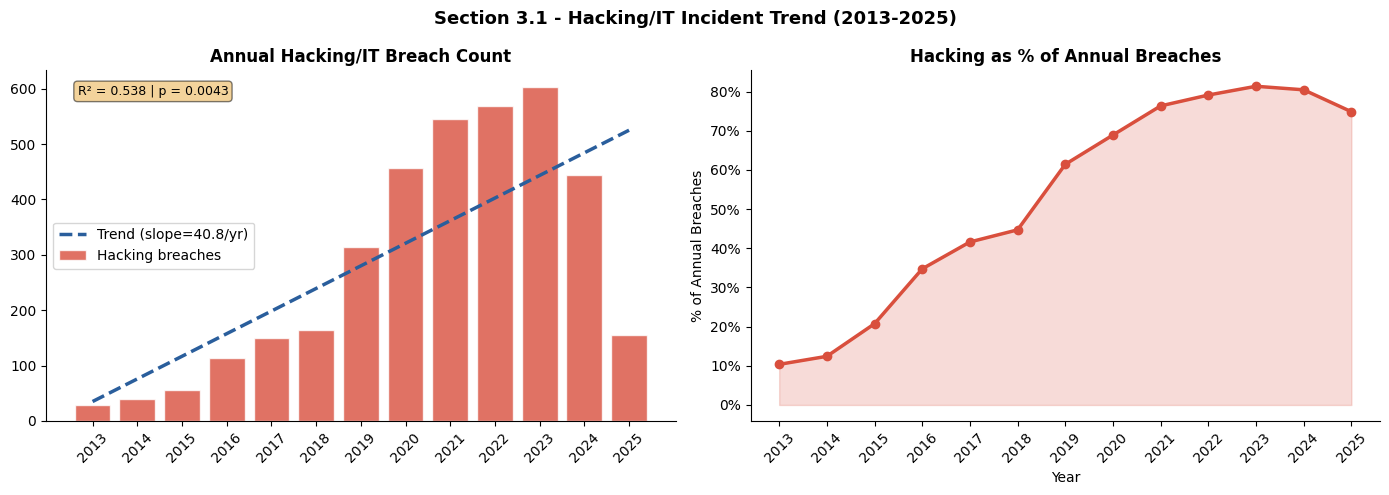


Key finding: [3.1] Hacking/IT incidents show a significant upward trend (slope=40.8 breaches/year, R²=0.538).


In [141]:
trend_line = slope * years + intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 3.1 - Hacking/IT Incident Trend (2013-2025)', fontweight='bold', fontsize=13)

axes[0].bar(years, hack_counts, color=HACKING_C, alpha=0.8, edgecolor='white', label='Hacking breaches')
axes[0].plot(years, trend_line, color=DARK, linewidth=2.5, linestyle='--', label=f'Trend (slope={slope:.1f}/yr)')
axes[0].set_title('Annual Hacking/IT Breach Count', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(years)
axes[0].tick_params(axis='x', rotation=45)
axes[0].text(0.05, 0.93, f'R² = {r**2:.3f} | p = {p_val:.4f}', transform=axes[0].transAxes, fontsize=9, 
             bbox=dict(boxstyle='round,pad=0.3', facecolor=ACCENT, alpha=0.5))
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(years, hack_share, color=HACKING_C, linewidth=2.5, marker='o', markersize=6)
axes[1].fill_between(years, hack_share, alpha=0.2, color=HACKING_C)
axes[1].set_title('Hacking as % of Annual Breaches', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of Annual Breaches')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].set_xticks(years)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/03_3a_hacking_trend.png', bbox_inches='tight')
plt.show()

findings.append(f"[3.1] Hacking/IT incidents show a {trend_sig} (slope={slope:.1f} breaches/year, R²={r**2:.3f}).")
print(f"\nKey finding: {findings[-1]}")

The left chart confirms a significant upward trend in raw counts through 2023 with a notable dip in 2024-2025. 

The right chart shows that hacking's share of all breaches grew from ~10% in 2013 to ~80% by 2022-2024. Hacking didn't just increase but also displaced other breach types entirely. 

The drop in raw counts for 2024 and especially 2025 is likely a reporting lag and not a real decline. Although already filtering `df_full` to 2013-2025, 2025 may still be underrepresented. 

#### 3.2 Decline in Physical Breaches

In [142]:
phys_types = ['Theft', 'Loss', 'Improper Disposal']

phys_avail = [p for p in phys_types if p in yearly_type.columns]
phys_total = yearly_type[phys_avail].sum(axis=1).values
slope_p, intercept_p, r_p, p_p, _ = stats.linregress(years, phys_total)
phys_trend = 'declining' if slope_p < 0 else 'increasing'

print(f"Linear regression - Physical breaches vs Year:")
print(f"Slope:      {slope_p:.2f} breaches/year")
print(f"R²:         {r_p**2:.3f}")
print(f"p-value:    {p_p:.6f}")
print(f"Trend:      {phys_trend}")

Linear regression - Physical breaches vs Year:
Slope:      -12.23 breaches/year
R²:         0.912
p-value:    0.000000
Trend:      declining


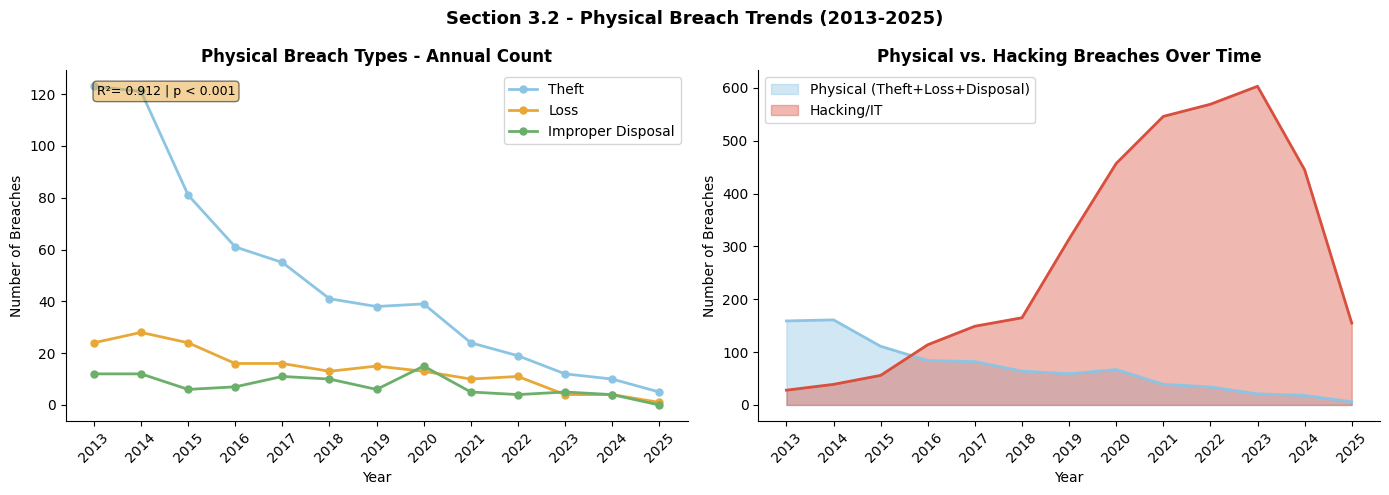


Key Finding: [3.2] Physical breaches (Theft, Loss, Improper Disposal) are declining (slope=-12.2/year, p < 0.001), suggesting improving physical safeguard compliance over time.


In [143]:
colors_phys = [PHYS_C, ACCENT, PALETTE[5]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 3.2 - Physical Breach Trends (2013-2025)', fontweight='bold', fontsize=13)

for pt, color in zip(phys_avail, colors_phys):
    vals = yearly_type[pt].values
    axes[0].plot(years, vals, marker='o', linewidth=2, color=color, label=pt, markersize=5)
axes[0].set_title('Physical Breach Types - Annual Count', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Breaches')
axes[0].legend()
axes[0].set_xticks(years)
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].text(0.05, 0.93, f'R²= {r_p**2:.3f} | p < 0.001', transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=ACCENT, alpha=0.5))

hack_vals = yearly_type.get('Hacking/IT Incident', pd.Series(0, index=years)).values
axes[1].fill_between(years, phys_total, alpha=0.4, color=PHYS_C, label='Physical (Theft+Loss+Disposal)')
axes[1].fill_between(years, hack_vals, alpha=0.4, color=HACKING_C, label='Hacking/IT')
axes[1].plot(years, phys_total, color=PHYS_C, linewidth=2)
axes[1].plot(years, hack_vals, color=HACKING_C, linewidth=2)
axes[1].set_title('Physical vs. Hacking Breaches Over Time', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Breaches')
axes[1].legend()
axes[1].set_xticks(years)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/03_3b_physical_breach_trend.png', bbox_inches='tight')
plt.show()

p_display = '< 0.001' if p_p < 0.001 else f'{p_p:.4f}'
findings.append(f"[3.2] Physical breaches (Theft, Loss, Improper Disposal) are {phys_trend} (slope={slope_p:.1f}/year, p {p_display}), suggesting {'improving physical safeguard compliance over time' if phys_trend == 'declining' else 'physical safeguard controls have not improved'}.")
print(f"\nKey Finding: {findings[-1]}")

Theft, Loss, and Improper Disposal are the physical breach types that have declined sharply and consistently since 2013 with a strong linear trend (slope=-12.2/year, R²=0.912, p< 0.001). Theft, which was the dominant physical breach type in the early years of the dataset, has fallen from 120 incidents in 2013 to near zero by 2025. Loss and Improper Disposal followed similar trajectories, though from lower baselines. This likely reflects cumulative improvements in physical safeguard compliance following HIPPA enforcement and device encryption adoption. 

The right panel tells the broader story that while physical breaches declines, hacking volume surged past them around 2016-2017 and has dominated ever since. Physical controls have improved but technical safeguard gaps have filled the void.

#### 3.3 Are Mega-Breaches Increasing?

In [144]:
yearly_mega = df_full.groupby('year')['is_mega_breach'].agg(
    Count='sum',
    Rate='mean'
).reset_index()

peak_year = yearly_mega.loc[yearly_mega['Count'].idxmax(), 'year']
peak_count = int(yearly_mega['Count'].max())

print(f"Mega-breach (>1M individuals) summary:")
print(f"Total mega-breaches: {int(yearly_mega['Count'].sum())}")
print(f"Peak Year: {peak_year} ({peak_count} events)")
yearly_mega

Mega-breach (>1M individuals) summary:
Total mega-breaches: 102
Peak Year: 2023 (37 events)


,year,Count,Rate
0,2013,1,0.003704
1,2014,4,0.012739
2,2015,6,0.022222
3,2016,3,0.009146
4,2017,0,0.000000
5,2018,4,0.010840
6,2019,7,0.013699
7,2020,6,0.009050
8,2021,15,0.020979
9,2022,12,0.016690


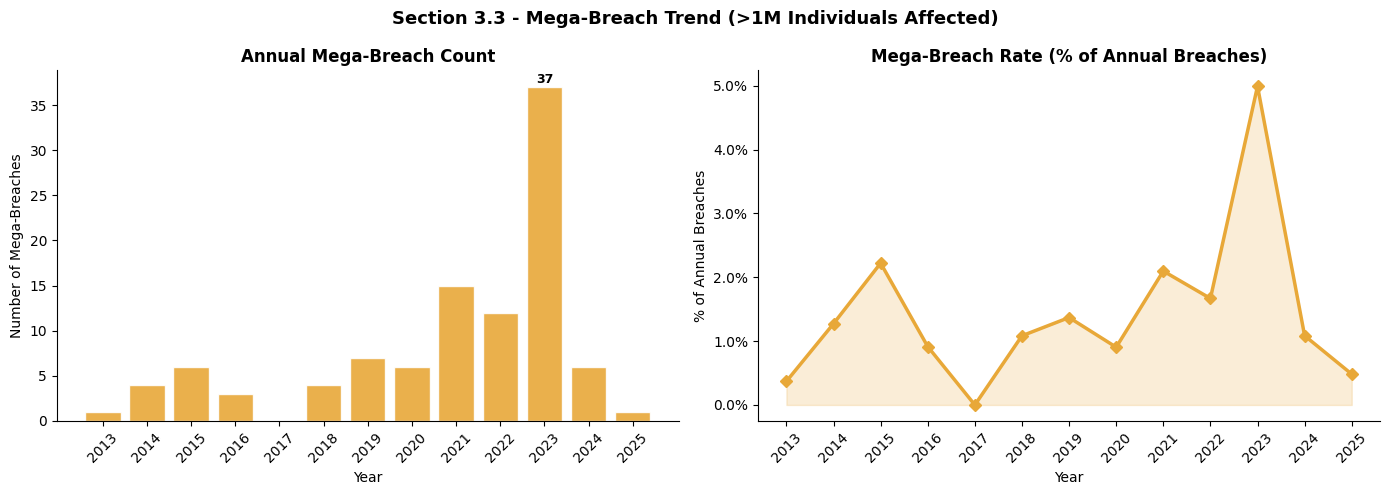


Key Findings: [3.3] Mega-breaches (>1M individuals affected) peaked in 2023 with 37 events, highlighting concentrated catastrophic-risk years.


In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 3.3 - Mega-Breach Trend (>1M Individuals Affected)', fontweight='bold', fontsize=13)

axes[0].bar(yearly_mega['year'], yearly_mega['Count'], color=ACCENT, edgecolor='white', alpha=0.9)
axes[0].set_title('Annual Mega-Breach Count', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Mega-Breaches')
axes[0].set_xticks(yearly_mega['year'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].text(peak_year, peak_count + 0.5, str(peak_count), ha='center', fontsize=9, fontweight='bold')

axes[1].plot(yearly_mega['year'], yearly_mega['Rate'] * 100, color=ACCENT, linewidth=2.5, marker='D', markersize=6)
axes[1].fill_between(yearly_mega['year'], yearly_mega['Rate'] * 100, alpha=0.2, color=ACCENT)
axes[1].set_title('Mega-Breach Rate (% of Annual Breaches)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of Annual Breaches')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticks(yearly_mega['year'])
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/03_3c_mega_breach_trend.png', bbox_inches='tight')
plt.show()

findings.append(f"[3.3] Mega-breaches (>1M individuals affected) peaked in {peak_year} with {peak_count} events, highlighting concentrated catastrophic-risk years.")
print(f"\nKey Findings: {findings[-1]}")

Mega-breach years are relevant not just as outliers but as indicators of systemic risk concentration as a single mega-breach can expose more individuals than hundreds of smaller breaches combined. While mega-breaches remain rare in absolute terms, both their count and rate have trended upward since 2013, with the the 2023 spike (37 events, nearly 5% of all breaches that year) representing a significant escalation likely driven by large-scale ransomware attacks on healthcare vendors serving multiple covered entities at the same time. 

As with section 3.1, the apparent decline in 2024-2025 should be interpreted cautiously given HHS reporting lags for recent years.  

### 4. Gap Identification

Gap identification is the analytical core of this project. The goal is to move beyond description and answer which HIPAA safeguard categories perform poorly relative to the harm they cause. A safeguard category whose frequency and impact are similar represents a known and manageable risk. However, when a category's share of the total impact is much greater that its share of incidents, it indicates a systematic control failure. In these cases, breaches occur less often but cause disproportionately severe consequences when they do occur. 

#### 4.1 Frequency Share vs. Impact Share

In [146]:
gap_freq = df['breach_type_gap'].value_counts()
gap_impact = df.groupby('breach_type_gap')['individuals_affected'].sum()

gap_df = pd.DataFrame({
    'Breach Count': gap_freq,
    'Total Individuals': gap_impact,
}).dropna()

gap_df['Freq Share %'] = gap_df['Breach Count'] / gap_df['Breach Count'].sum() * 100
gap_df['Impact Share %'] = gap_df['Total Individuals'] / gap_df['Total Individuals'].sum() * 100
gap_df['Impact/Freq Ratio'] = gap_df['Impact Share %'] / gap_df['Freq Share %']
gap_df = gap_df.sort_values('Impact/Freq Ratio', ascending=False)

print("Control gap frequency vs. impact breakdown:")
gap_df.round(2)

Control gap frequency vs. impact breakdown:


,Breach Count,Total Individuals,Freq Share %,Impact Share %,Impact/Freq Ratio
breach_type_gap,,,,,
Technical Safeguard Failure,3648,565544899,60.51,91.56,1.51
Physical/Technical Safeguard Failure,808,19609259,13.40,3.17,0.24
Physical/Administrative Safeguard Failure,97,2044790,1.61,0.33,0.21
Administrative Safeguard Failure,1429,29851630,23.70,4.83,0.20
Unclassified,47,646942,0.78,0.10,0.13


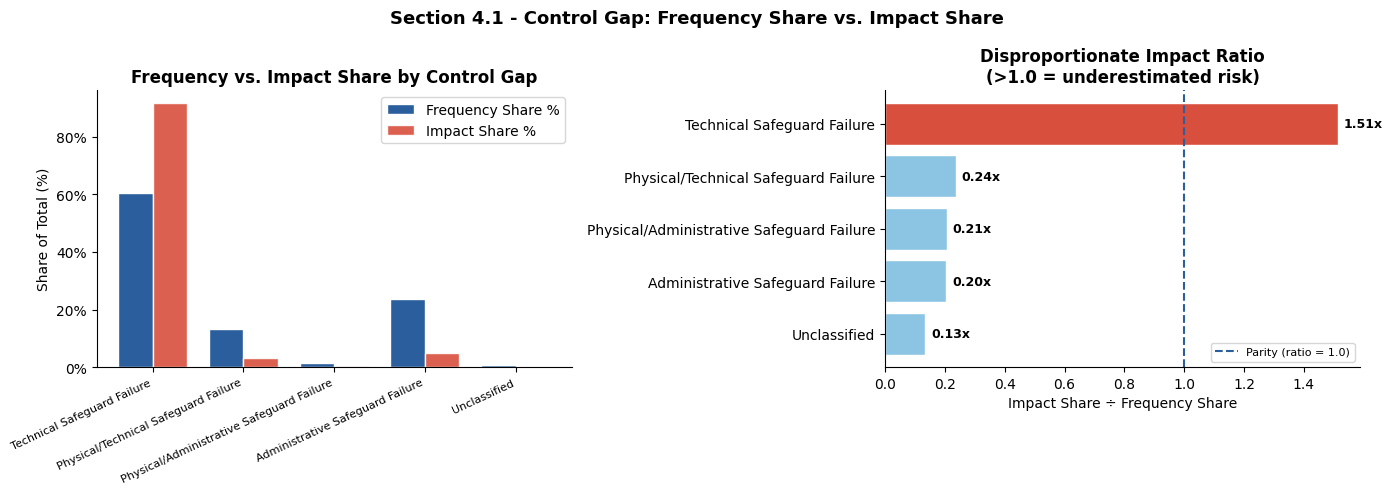


Key Finding: [4.1] 'Technical Safeguard Failure' is the most disproportionately impactful control gap - its impact share is 1.51x its frequency share, indicating systemic under-mitigation of this risk category.


In [147]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4.1 - Control Gap: Frequency Share vs. Impact Share', fontweight='bold', fontsize=13)

x, w = np.arange(len(gap_df)), 0.38
axes[0].bar(x - w/2, gap_df['Freq Share %'], w, color=DARK, label='Frequency Share %', edgecolor='white')
axes[0].bar(x + w/2, gap_df['Impact Share %'], w, color=HACKING_C, label='Impact Share %', edgecolor='white', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gap_df.index, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Share of Total (%)')
axes[0].set_title('Frequency vs. Impact Share by Control Gap', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

ratio_colors = [HACKING_C if r > 1.5 else PALETTE[1] if r > 0.8 else PHYS_C
                for r in gap_df['Impact/Freq Ratio']]
bars = axes[1].barh(gap_df.index[::-1], gap_df['Impact/Freq Ratio'][::-1], color=ratio_colors[::-1], edgecolor='white')
axes[1].axvline(x=1.0, color=DARK, linewidth=1.5, linestyle='--', label='Parity (ratio = 1.0)')
axes[1].set_xlabel('Impact Share ÷ Frequency Share')
axes[1].set_title('Disproportionate Impact Ratio\n(>1.0 = underestimated risk)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, gap_df['Impact/Freq Ratio'][::-1]):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}x', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_4a_gap_frequency_vs_impact.png', bbox_inches='tight')
plt.show()

top_gap = gap_df.index[0]
top_gap_ratio = gap_df['Impact/Freq Ratio'].iloc[0]
findings.append(f"[4.1] '{top_gap}' is the most disproportionately impactful control gap - its impact share is {top_gap_ratio:.2f}x its frequency share, indicating systemic under-mitigation of this risk category.")
print(f"\nKey Finding: {findings[-1]}")

The disproportionate impact ratio reveals which control gaps punch above their weight in terms of patient exposure. Technical Safeguard Failure stands out as it accounts for 60.5% of breaches but 91.6% of all individuals affected. Every other gap category has a ratio below 0.25x, meaning they are over-represented in breach counts relative to their actual impact. 

This confirms that technical safeguard failures are not just the most frequent gap but systematically the most damaging, making them the highest-priority category for investment in controls such as network segmentation, endpoint detection, and access management. 

#### 4.2 High-Severity Gap Summary Table

In [148]:
gap_summary = gap_df.copy()
gap_summary['Median Individuals'] = df.groupby('breach_type_gap')['individuals_affected'].median()
gap_summary['Severity Tier'] = pd.cut(
    gap_summary['Impact/Freq Ratio'],
    bins=[0, 0.8, 1.5, float('inf')],
    labels=['Under-represented Risk', 'Proportionate Risk', 'Disproportionate Risk']
)

gap_summary = gap_summary.reset_index().rename(columns={'breach_type_gap': 'Control Gap Category'})

print("Gap severity tiers:")
print(gap_summary.groupby('Severity Tier', observed=True).size().to_string())
gap_summary

Gap severity tiers:
Severity Tier
Under-represented Risk    4
Disproportionate Risk     1


,Control Gap Category,Breach Count,Total Individuals,Freq Share %,Impact Share %,Impact/Freq Ratio,Median Individuals,Severity Tier
0,Technical Safeguard Failure,3648,565544899,60.507547,91.556932,1.513149,8394.0,Disproportionate Risk
1,Physical/Technical Safeguard Failure,808,19609259,13.401891,3.174573,0.236875,2000.0,Under-represented Risk
2,Physical/Administrative Safeguard Failure,97,2044790,1.608890,0.331034,0.205753,2000.0,Under-represented Risk
3,Administrative Safeguard Failure,1429,29851630,23.702106,4.832726,0.203894,1708.0,Under-represented Risk
4,Unclassified,47,646942,0.779565,0.104734,0.134350,1920.0,Under-represented Risk


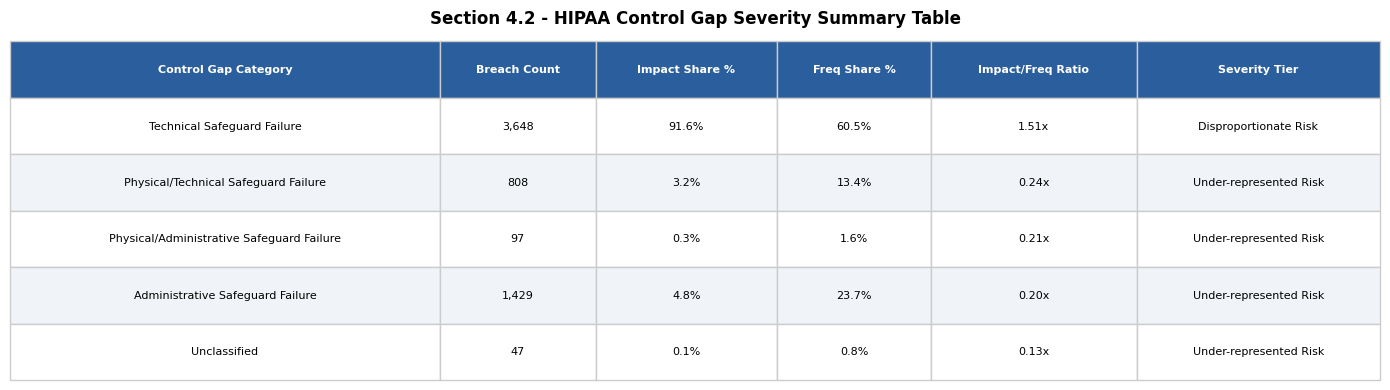


Key Finding: [4.2] Of 5 control gap categories, 1 is classified as Disproportionate Risk ('Technical Safeguard Failure', ratio=1.51x) and 4 as Under-represented Risk, confirming a single dominant gap drives the majority of breach impact.


In [149]:
import matplotlib.patches as mpatches

display_cols = ['Control Gap Category', 'Breach Count', 'Impact Share %', 'Freq Share %', 'Impact/Freq Ratio', 'Severity Tier']
display_data = gap_summary[display_cols].copy()
display_data['Impact Share %'] = display_data['Impact Share %'].map('{:.1f}%'.format)
display_data['Freq Share %'] = display_data['Freq Share %'].map('{:.1f}%'.format)
display_data['Impact/Freq Ratio'] = display_data['Impact/Freq Ratio'].map('{:.2f}x'.format)
display_data['Breach Count'] = display_data['Breach Count'].map('{:,.0f}'.format)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(
    cellText=display_data.values,
    colLabels=display_cols,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(DARK)
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F0F4F8')
    cell.set_edgecolor('#CCCCCC')
table.auto_set_column_width(col=list(range(len(display_cols))))
ax.set_title('Section 4.2 - HIPAA Control Gap Severity Summary Table', fontweight='bold', fontsize='12', pad=8, y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/03_4b_gap_summary_table.png', bbox_inches='tight', dpi=150)
plt.show()

disp_count = (gap_summary['Severity Tier'] == 'Disproportionate Risk').sum()
under_count = (gap_summary['Severity Tier'] == 'Under-represented Risk').sum()
total_gaps = len(gap_summary)
disp_name = gap_summary[gap_summary['Severity Tier'] == 'Disproportionate Risk']['Control Gap Category'].iloc[0]
disp_ratio = gap_summary[gap_summary['Severity Tier'] == 'Disproportionate Risk']['Impact/Freq Ratio'].iloc[0]


findings.append(f"[4.2] Of {total_gaps} control gap categories, {disp_count} is classified as Disproportionate Risk ('{disp_name}', ratio={disp_ratio:.2f}x) and {under_count} as Under-represented Risk, confirming a single dominant gap drives the majority of breach impact.")
print(f"\nKey Finding: {findings[-1]}")

The severity classification framework helps organizations prioritize remediation efforts by focusing resources on safeguard gaps that cause the greatest harm, rather than those that occur most often. 

Technical Safeguard Failure is the only category classified as a Disproportionate Risk across the dataset. Combined with the trend analysis in Section 3, which shows a steady increase in hacking incidents since 2013, this suggests a growing weakness in technical safeguards among U.S. healthcare organizations.   

Administrative Safeguard Failure is the second most common category, accounting for 1,429 (23.7% of incidents), but it represents only 4.8% of the total impact. This indicates that, although these failures occur frequently, their consequences are generally less severe and may be better contained. 

For compliance and security teams, these findings provide a clear basis for prioritizing HIPAA remediation efforts: strengthen technical safeguards first and address administrative safeguards as a secondary priority.

#### 4.3 Export Key Findings & Gap Summary

In [150]:
gap_summary.to_csv('../data/processed/gap_summary.csv', index=False)
print(f"Exported: gap_summary.csv ({len(gap_summary)} rows)")

Exported: gap_summary.csv (5 rows)


In [151]:
with open('../reports/key_findings.txt', 'w') as f:
    f.write("HIPAA BREACH ANALYSIS - KEY FINDINGS\n")
    f.write("=" * 60 + "\n")
    f.write(f"Dataset: {len(df):,} breaches | {df['year'].min()}-{df['year'].max()}\n")
    f.write(f"Total individuals affected: {df['individuals_affected'].sum():,.0f}\n")
    f.write("=" * 60 + "\n\n")
    for finding in findings:
        f.write(finding + "\n\n")

print(f"Exported: key_findings.txt ({len(findings)} findings)")

Exported: key_findings.txt (11 findings)
